#Лабораторная работа «Преобразование изображения»

In [4]:
!pip install opencv-python matplotlib numpy

Получите условно серое изображение: выделив все 3RGB-канала,получите результат их усреднения, а затем запишите его вместокаждогоизизначальных цветовых каналов. Выполните это для всех своих изображений.

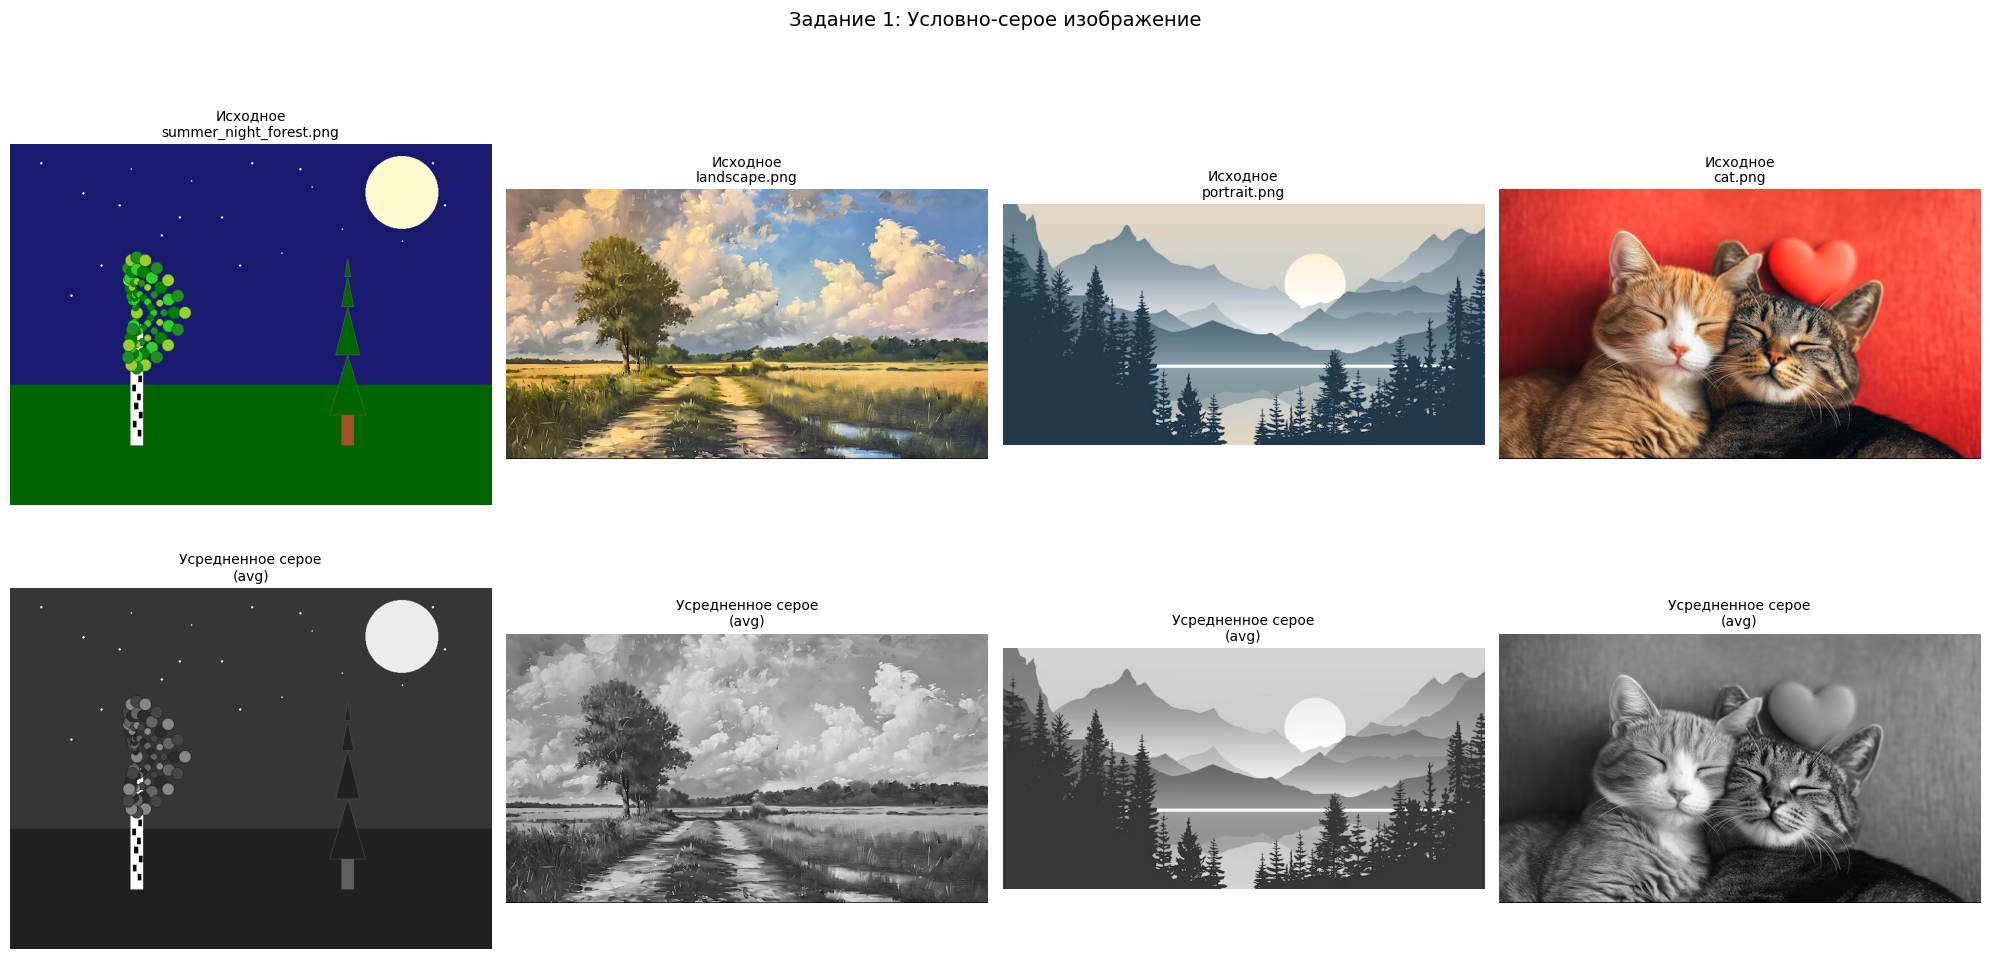

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

def create_conditional_grayscale(image_path, save_result=False):
    #Загружаем изображение в цвете
    img_bgr = cv2.imread(image_path)

    #Конвертируем из BGR в RGB для корректного отображения в matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray_avg = np.mean(img_rgb, axis=2).astype(np.uint8)

    #Создаем пустое изображение
    result_img = np.zeros_like(img_rgb)

    #Заполняем все три канала (R, G, B) усредненным значением
    result_img[:, :, 0] = gray_avg
    result_img[:, :, 1] = gray_avg
    result_img[:, :, 2] = gray_avg

    if save_result:
        base_name = os.path.splitext(image_path)[0]
        output_path = base_name + "_gray_avg.jpg"
        result_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, result_bgr)

    return img_rgb, result_img

image_paths = [
    "summer_night_forest.png",
    "landscape.png",
    "portrait.png",
    "cat.png"
]


if num_images > 0:
    fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 10))

    if num_images == 1:
        axes = axes.reshape(2, 1)

    for idx, img_path in enumerate(existing_paths):
        original, gray_conditional = create_conditional_grayscale(img_path, save_result=True)

        if original is not None and gray_conditional is not None:
            axes[0, idx].imshow(original)
            axes[0, idx].set_title(f"Исходное\n{os.path.basename(img_path)}", fontsize=10)
            axes[0, idx].axis('off')

            axes[1, idx].imshow(gray_conditional)
            axes[1, idx].set_title("Усредненное серое\n(avg)", fontsize=10)
            axes[1, idx].axis('off')

    plt.suptitle('Задание 1: Условно-серое изображение', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Получите Grayscale-изображения (в градациях серого) с использованиемформулы Y = 0.2126⋅ R + 0.7152⋅ G + 0.0722⋅ B, часто применяемойвразличных графических пакетах для такого преобразования. ЗдесьR, GиBсоответствуют красному, зеленому и синему каналам.

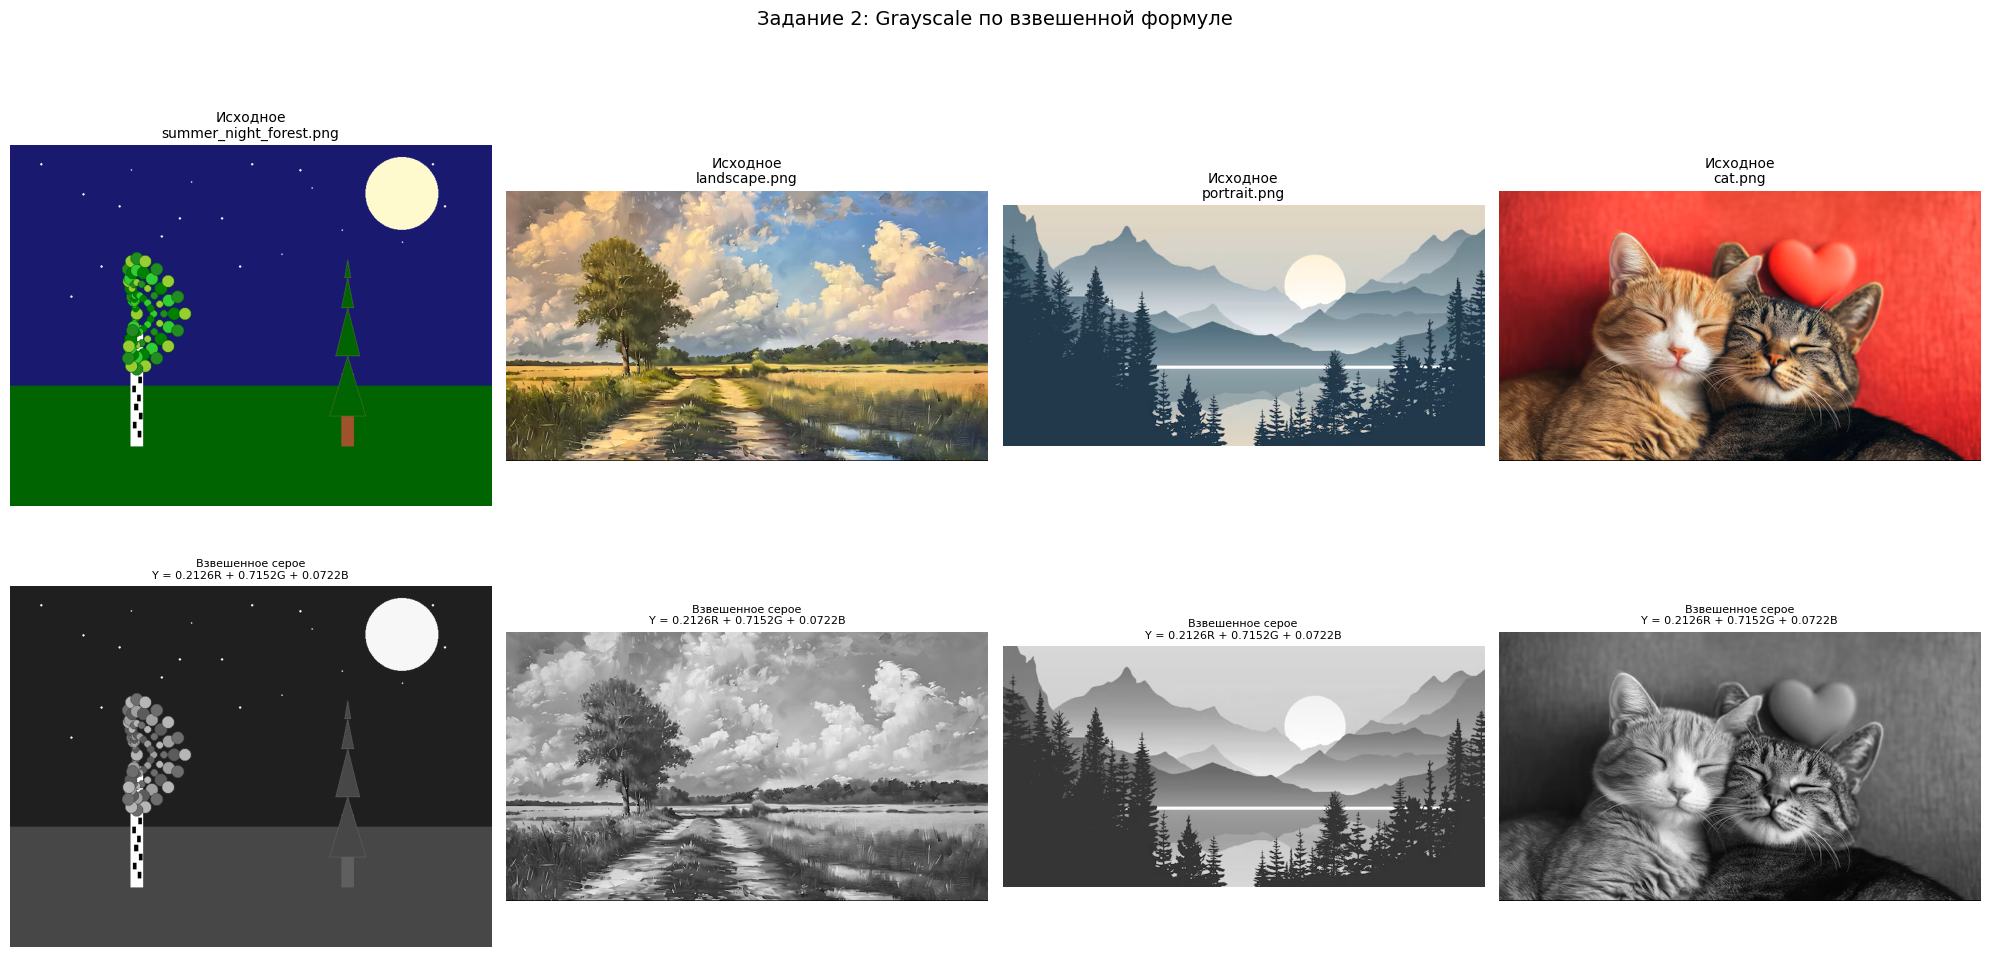

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

def create_weighted_grayscale(image_path, save_result=False):
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        print(f"Ошибка: не удалось загрузить изображение {image_path}")
        return None, None

    # Конвертируем из BGR в RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Разделяем каналы
    r = img_rgb[:, :, 0].astype(np.float32)
    g = img_rgb[:, :, 1].astype(np.float32)
    b = img_rgb[:, :, 2].astype(np.float32)

    # Применяем взвешенную формулу
    gray_weighted = (0.2126 * r + 0.7152 * g + 0.0722 * b).astype(np.uint8)

    # Создаем RGB изображение с одинаковыми каналами
    result_img = np.zeros_like(img_rgb)
    result_img[:, :, 0] = gray_weighted
    result_img[:, :, 1] = gray_weighted
    result_img[:, :, 2] = gray_weighted

    if save_result:
        base_name = os.path.splitext(image_path)[0]
        output_path = base_name + "_gray_weighted.jpg"
        result_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, result_bgr)

    return img_rgb, result_img

# Список изображений
image_paths = [
    "summer_night_forest.png",
    "landscape.png",
    "portrait.png",
    "cat.png"
]

# Проверяем, какие файлы существуют
existing_paths = [p for p in image_paths if os.path.exists(p)]
num_images = len(existing_paths)  # <--- ЭТО БЫЛО ПРОПУЩЕНО

if num_images > 0:
    fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 10))

    if num_images == 1:
        axes = axes.reshape(2, 1)

    for idx, img_path in enumerate(existing_paths):
        original, gray_weighted = create_weighted_grayscale(img_path, save_result=True)

        if original is not None and gray_weighted is not None:
            axes[0, idx].imshow(original)
            axes[0, idx].set_title(f"Исходное\n{os.path.basename(img_path)}", fontsize=10)
            axes[0, idx].axis('off')

            axes[1, idx].imshow(gray_weighted)
            axes[1, idx].set_title("Взвешенное серое\nY = 0.2126R + 0.7152G + 0.0722B", fontsize=8)
            axes[1, idx].axis('off')

    plt.suptitle('Задание 2: Grayscale по взвешенной формуле', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено ни одного изображения. Проверьте пути к файлам.")

Получите Grayscale-изображения (в градациях серого) с использованиемметода grayscale из модуля ImageOps библиотеки PIL.

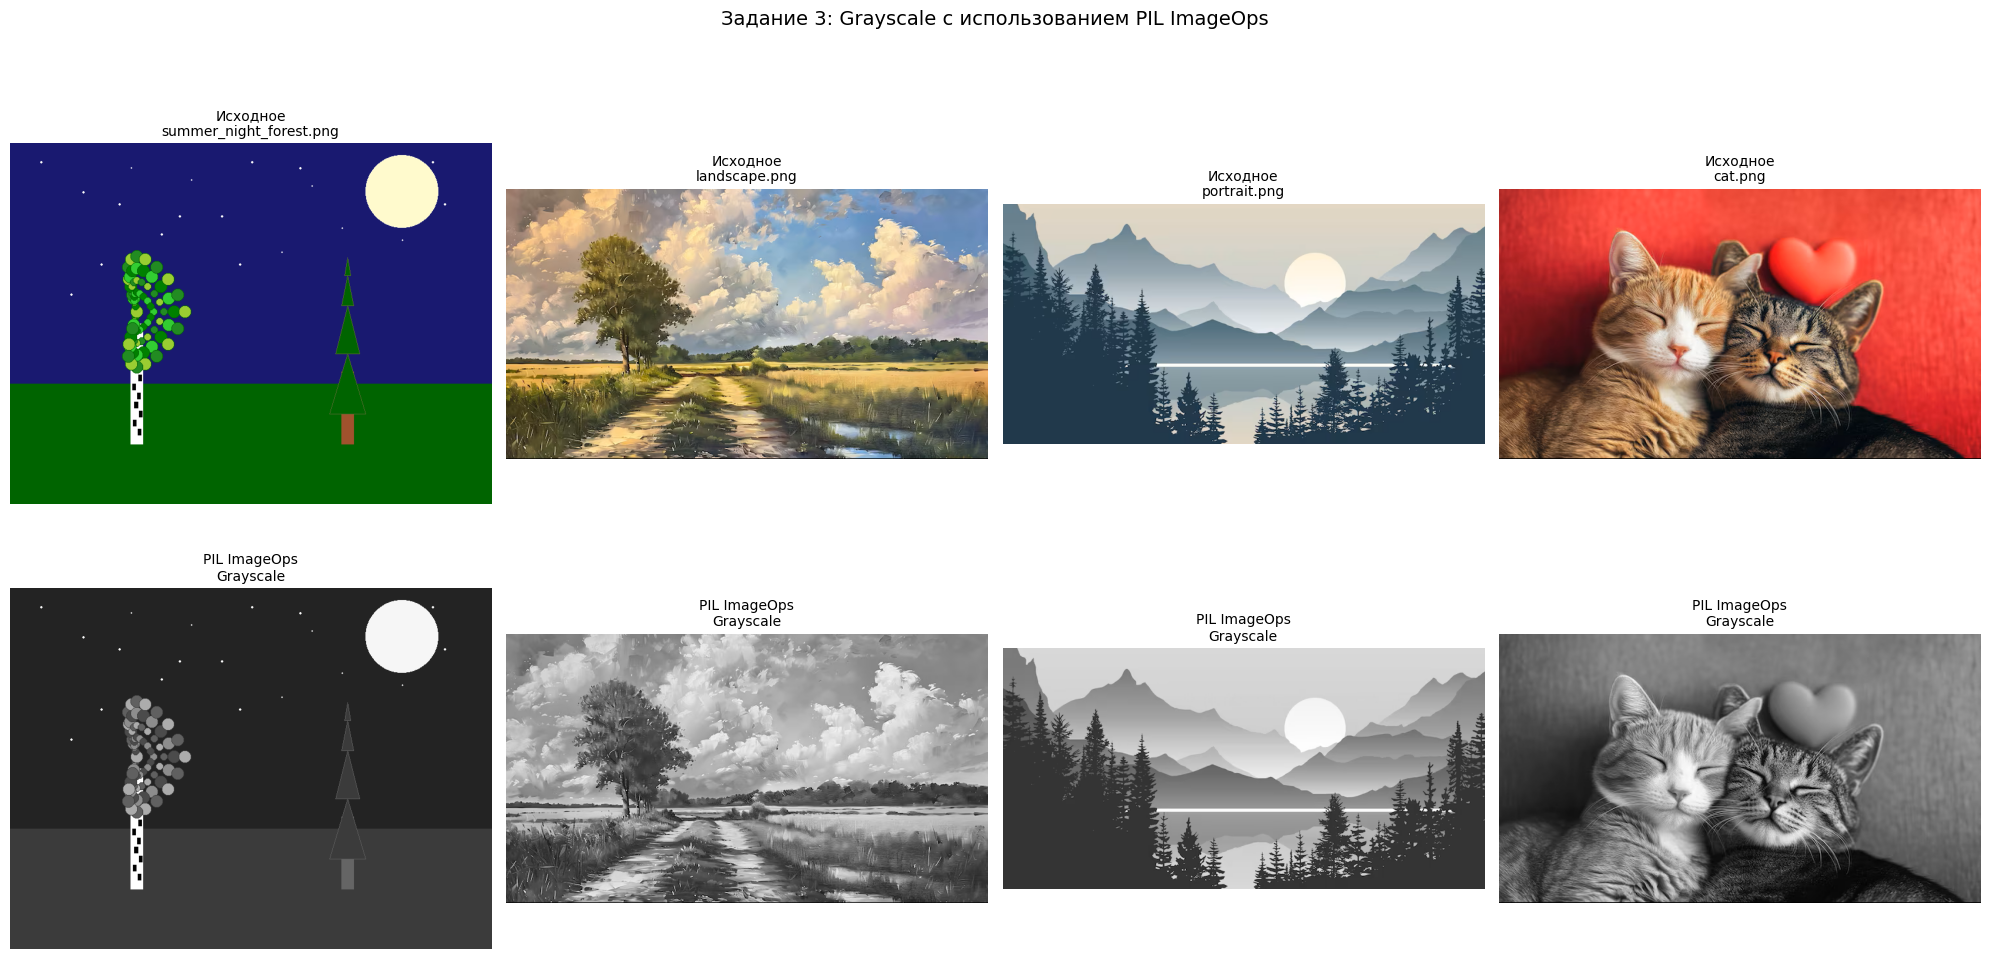

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image, ImageOps

def create_pil_grayscale(image_path, save_result=False):
    #Загружаем изображение с помощью PIL
    try:
        img_pil = Image.open(image_path)
    except:
        print(f"Ошибка: {image_path}")
        return None, None

    #Конвертируем в RGB для единообразия
    img_rgb_pil = img_pil.convert('RGB')

    #Используем ImageOps.grayscale для преобразования
    gray_pil = ImageOps.grayscale(img_rgb_pil)

    #Конвертируем обратно в RGB для отображения
    gray_rgb_pil = gray_pil.convert('RGB')

    #Конвертируем в numpy array
    img_rgb = np.array(img_rgb_pil)
    result_img = np.array(gray_rgb_pil)

    if save_result:
        base_name = os.path.splitext(image_path)[0]
        output_path = base_name + "_gray_pil.jpg"
        gray_pil.save(output_path)

    return img_rgb, result_img

image_paths = [
    "summer_night_forest.png",
    "landscape.png",
    "portrait.png",
    "cat.png"
]


if num_images > 0:
    fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 10))

    if num_images == 1:
        axes = axes.reshape(2, 1)

    for idx, img_path in enumerate(existing_paths):
        original, gray_pil = create_pil_grayscale(img_path, save_result=True)

        if original is not None and gray_pil is not None:
            axes[0, idx].imshow(original)
            axes[0, idx].set_title(f"Исходное\n{os.path.basename(img_path)}", fontsize=10)
            axes[0, idx].axis('off')

            axes[1, idx].imshow(gray_pil)
            axes[1, idx].set_title("PIL ImageOps\nGrayscale", fontsize=10)
            axes[1, idx].axis('off')

    plt.suptitle('Задание 3: Grayscale с использованием PIL ImageOps', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

4. Проанализируйте полученные изображения. Есть ли разницавкартинках,полученных с помощью различных применённых преобразований?

Анализ

Файл: summer_night_forest.png
Средняя яркость:
  Усреднение: 53.1
  Взвешенный: 53.2
  PIL: 51.3

Разница между методами:
  Усреднение vs Взвешенный: 28.1
  Усреднение vs PIL: 21.3
  Взвешенный vs PIL: 6.8

Преобладает: Синий
-> Усреднение и взвешенный метод отличаются


Файл: landscape.png
Средняя яркость:
  Усреднение: 138.0
  Взвешенный: 142.4
  PIL: 142.8

Разница между методами:
  Усреднение vs Взвешенный: 5.9
  Усреднение vs PIL: 6.3
  Взвешенный vs PIL: 0.9

Преобладает: Красный
-> PIL и взвешенный метод почти одинаковы


Файл: portrait.png
Средняя яркость:
  Усреднение: 136.7
  Взвешенный: 136.6
  PIL: 136.2

Разница между методами:
  Усреднение vs Взвешенный: 1.6
  Усреднение vs PIL: 2.2
  Взвешенный vs PIL: 0.7

Преобладает: Синий
-> PIL и взвешенный метод почти одинаковы


Файл: cat.png
Средняя яркость:
  Усреднение: 104.9
  Взвешенный: 97.6
  PIL: 105.4

Разница между методами:
  Усреднение vs Взвешенный: 9.5
  Усреднение vs PIL: 3.4
  Взвешенный vs PIL: 7.8

Преобл

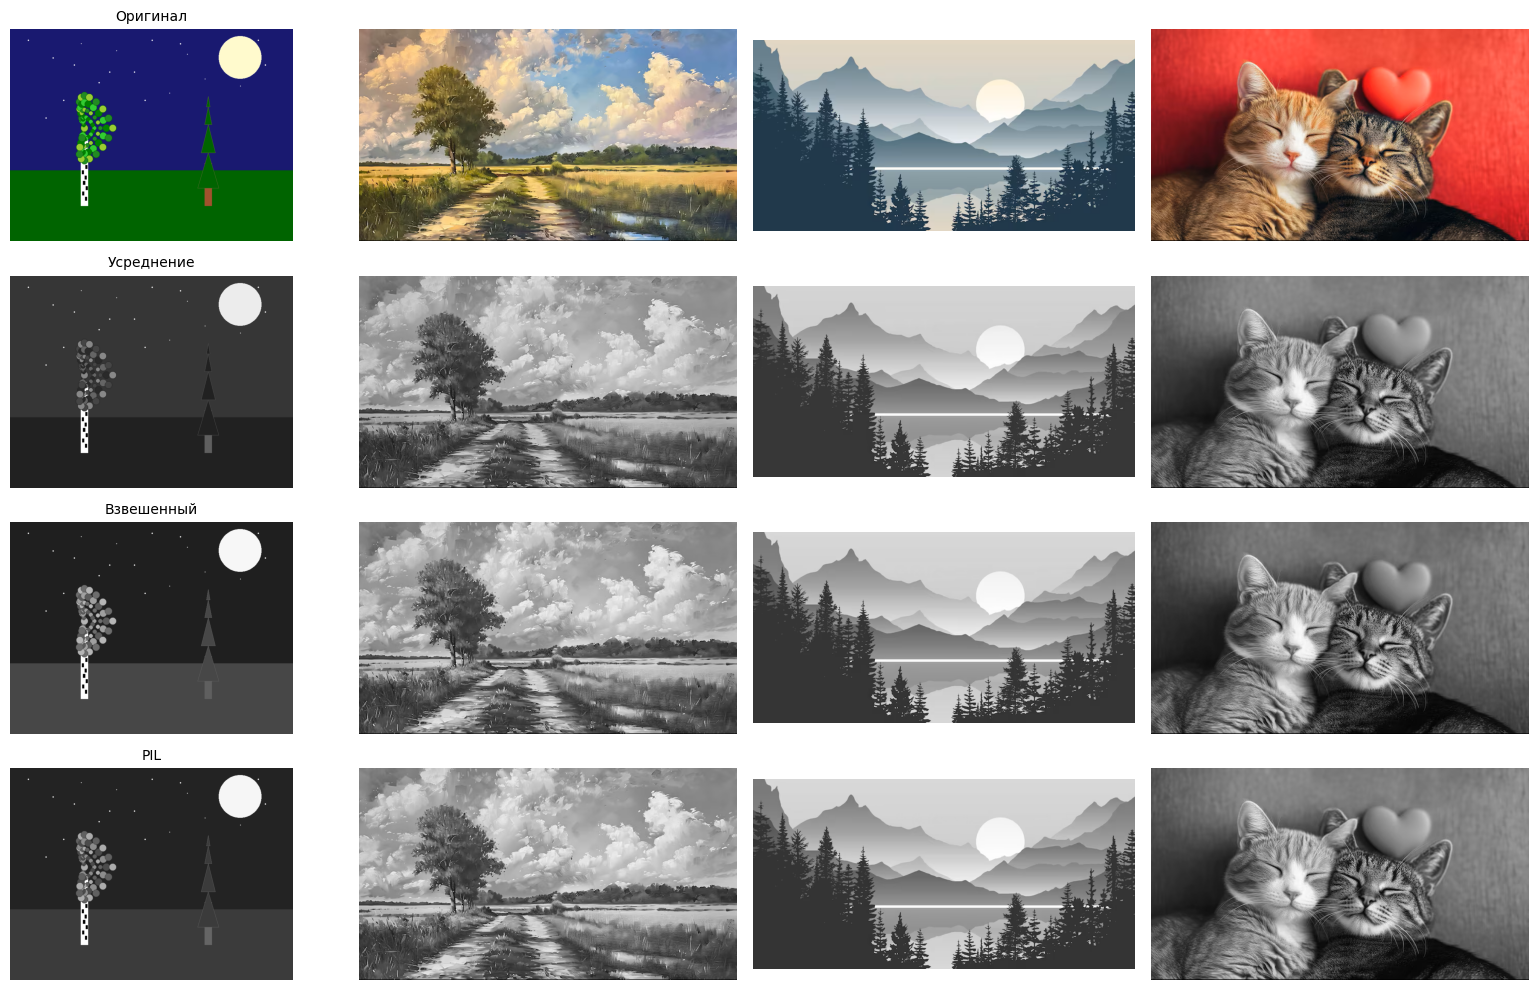

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image, ImageOps

#Функции преобразования
def avg_gray(path):
    img = cv2.imread(path)
    if img is None: return None, None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = np.mean(rgb, axis=2).astype(np.uint8)
    return rgb, np.dstack([gray, gray, gray])

def weighted_gray(path):
    img = cv2.imread(path)
    if img is None: return None, None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r, g, b = rgb[:,:,0].astype(float), rgb[:,:,1].astype(float), rgb[:,:,2].astype(float)
    gray = (0.2126*r + 0.7152*g + 0.0722*b).astype(np.uint8)
    return rgb, np.dstack([gray, gray, gray])

def pil_gray(path):
    try:
        img = Image.open(path).convert('RGB')
        gray = ImageOps.grayscale(img).convert('RGB')
        return np.array(img), np.array(gray)
    except:
        return None, None

#Анализ
def analyze_images(image_paths):
    print("Анализ")

    for path in [p for p in image_paths if os.path.exists(p)]:
        print(f"\nФайл: {os.path.basename(path)}")

        orig, g_avg = avg_gray(path)
        _, g_w = weighted_gray(path)
        _, g_pil = pil_gray(path)

        if orig is None: continue

        #Сравнение методов
        diff_avg_w = np.mean(np.abs(g_avg[:,:,0].astype(np.int16) - g_w[:,:,0].astype(np.int16)))
        diff_avg_pil = np.mean(np.abs(g_avg[:,:,0].astype(np.int16) - g_pil[:,:,0].astype(np.int16)))
        diff_w_pil = np.mean(np.abs(g_w[:,:,0].astype(np.int16) - g_pil[:,:,0].astype(np.int16)))

        print(f"Средняя яркость:")
        print(f"  Усреднение: {np.mean(g_avg[:,:,0]):.1f}")
        print(f"  Взвешенный: {np.mean(g_w[:,:,0]):.1f}")
        print(f"  PIL: {np.mean(g_pil[:,:,0]):.1f}")

        print(f"\nРазница между методами:")
        print(f"  Усреднение vs Взвешенный: {diff_avg_w:.1f}")
        print(f"  Усреднение vs PIL: {diff_avg_pil:.1f}")
        print(f"  Взвешенный vs PIL: {diff_w_pil:.1f}")

        #Какой цвет преобладает
        means = [np.mean(orig[:,:,i]) for i in range(3)]
        colors = ['Красный', 'Зеленый', 'Синий']
        print(f"\nПреобладает: {colors[np.argmax(means)]}")

        # ростые выводы
        if diff_avg_w > 10:
            print("-> Усреднение и взвешенный метод отличаются")
        if diff_w_pil < 3:
            print("-> PIL и взвешенный метод почти одинаковы")
        print()

# Визуализация
def show_comparison(image_paths):
    paths = [p for p in image_paths if os.path.exists(p)]
    if not paths: return

    fig, axes = plt.subplots(4, len(paths), figsize=(4*len(paths), 10))
    if len(paths) == 1: axes = axes.reshape(4, 1)

    titles = ['Оригинал', 'Усреднение', 'Взвешенный', 'PIL']

    for i, path in enumerate(paths):
        orig, g1 = avg_gray(path)
        _, g2 = weighted_gray(path)
        _, g3 = pil_gray(path)

        images = [orig, g1, g2, g3]
        for j, img in enumerate(images):
            axes[j, i].imshow(img)
            axes[j, i].set_title(titles[j] if i==0 else '', fontsize=10)
            axes[j, i].axis('off')

    plt.tight_layout()
    plt.show()

image_paths = ["summer_night_forest.png", "landscape.png", "portrait.png", "cat.png"]
analyze_images(image_paths)
show_comparison(image_paths)

Используя метод transpose, отразите свои изображения слеванаправо

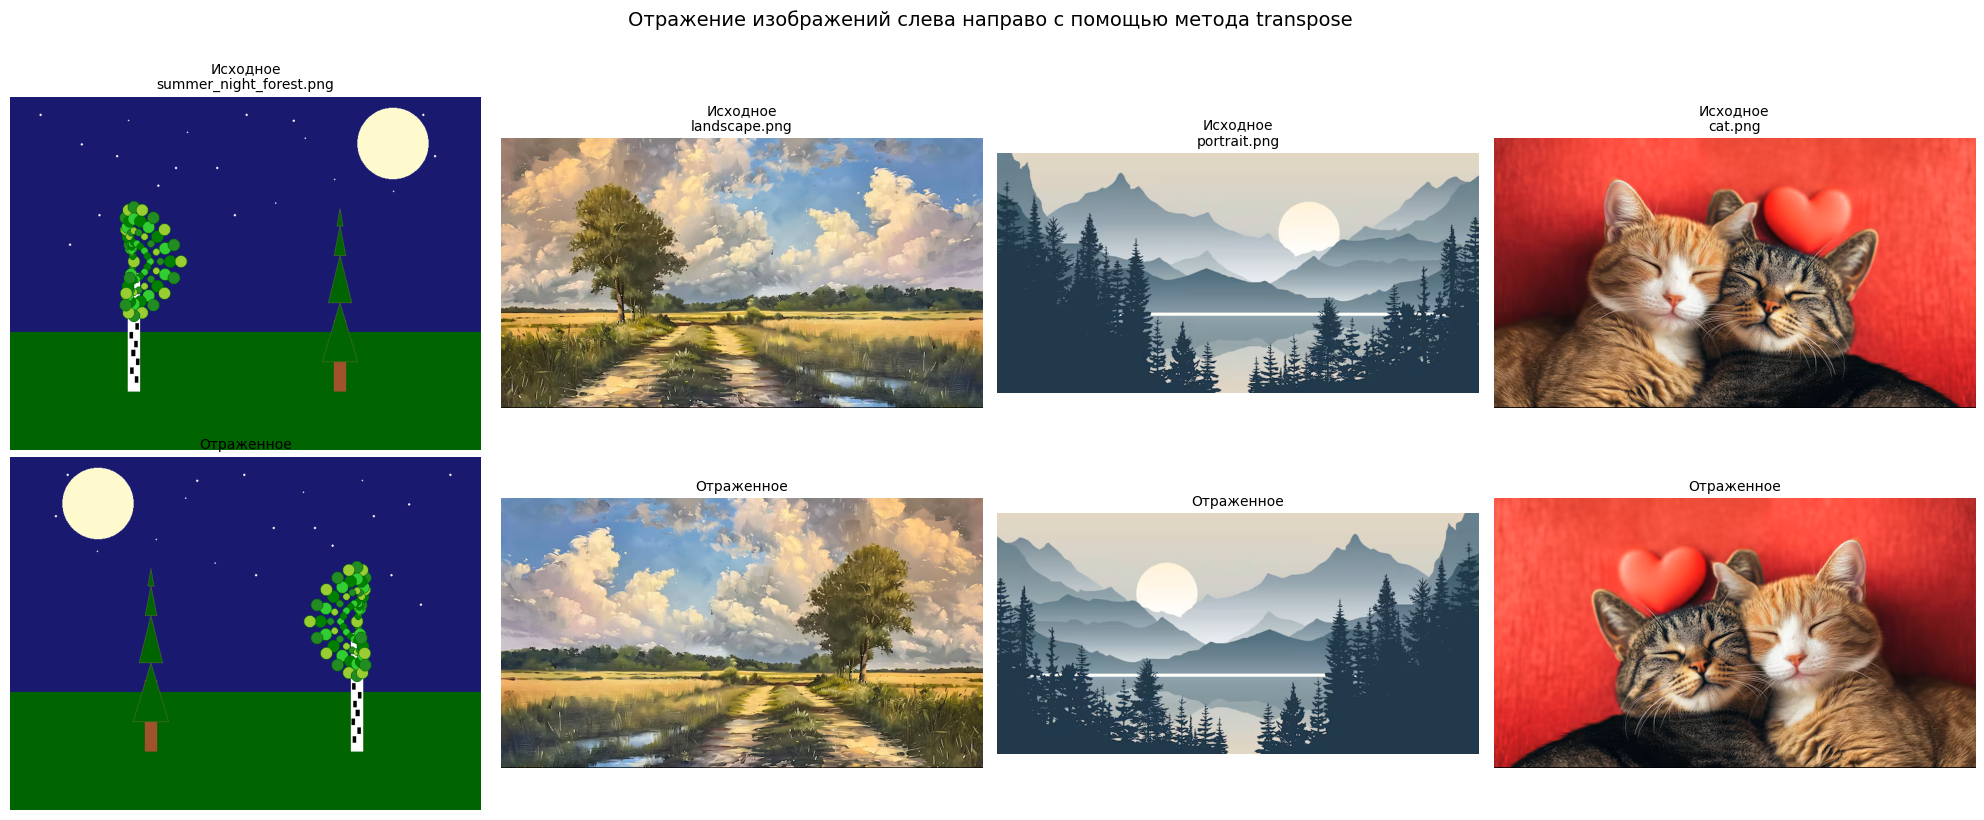

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

def flip_image_horizontal_pil(image_path, save_result=False):
    #Загружаем изображение с помощью PIL
    try:
        img_pil = Image.open(image_path)
    except:
        print(f"Ошибка:")
        return None

    #Конвертируем в RGB если есть альфа-канал
    if img_pil.mode == 'RGBA':
        background = Image.new('RGB', img_pil.size, (255, 255, 255))
        background.paste(img_pil, mask=img_pil.split()[3])
        img_pil = background
    else:
        img_pil = img_pil.convert('RGB')

    img_flipped = img_pil.transpose(Image.FLIP_LEFT_RIGHT)

    if save_result:
        base_name = os.path.splitext(image_path)[0]
        output_path = base_name + "_flipped.jpg"
        img_flipped.save(output_path, 'JPEG', quality=95)

    return np.array(img_flipped)

image_paths = [
    "summer_night_forest.png",
    "landscape.png",
    "portrait.png",
    "cat.png"
]

if num_images > 0:
    #Создаем сетку 2xN для отображения
    fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 8))

    if num_images == 1:
        axes = axes.reshape(2, 1)

    for idx, img_path in enumerate(existing_paths):
        img_pil = Image.open(img_path)
        if img_pil.mode == 'RGBA':
            background = Image.new('RGB', img_pil.size, (255, 255, 255))
            background.paste(img_pil, mask=img_pil.split()[3])
            original_rgb = np.array(background)
        else:
            original_rgb = np.array(img_pil.convert('RGB'))

        flipped = flip_image_horizontal_pil(img_path, save_result=True)

        axes[0, idx].imshow(original_rgb)
        axes[0, idx].set_title(f"Исходное\n{os.path.basename(img_path)}", fontsize=10)
        axes[0, idx].axis('off')

        axes[1, idx].imshow(flipped)
        axes[1, idx].set_title("Отраженное", fontsize=10)
        axes[1, idx].axis('off')

    plt.suptitle('Отражение изображений слева направо с помощью метода transpose', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()